In [10]:
#!/usr/bin/env python
# coding: utf-8
# (c) Charles Le Losq, Clément Ferraina 2023-2024
# see embedded licence file

#
# Library Loading
#
import pandas as pd # manipulate dataframes
import matplotlib.pyplot as plt # plotting
import numpy as np
np.random.seed = 167 # fix random seed for reproducibility

# local imports
import gpvisc

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
import joblib

# CPU or GPU?
device = gpvisc.get_device()

Will run on cuda


# Loading data and models

In [11]:
# Data loading
print("Loading the viscosity datasets...")
ds = gpvisc.data_loader()

# Add scalers
ds.scaler_tpx = StandardScaler().fit(ds.TPX_train_valid[:,:14]) # for the blackbox model

print("Loading the models...")
#Linear Regression
clf_linreg = joblib.load('./models/clf_linreg.joblib')

# Support Vector Machine regression
clf_svr = joblib.load('./models/clf_svr.joblib')

# Artificial Neural Network
clf_nn = joblib.load('./models/clf_nn.joblib')

# XGBoost model
clf_xgb = joblib.load('./models/clf_xgb.joblib')

# Greybox ANN and GP
gp_model, likelihood = gpvisc.load_gp_model(model_number=1, device=device)

print('Loaded.')

Loading the viscosity datasets...
Loading the models...


/home/charles/miniconda3/envs/gpvisc/lib/python3.11/site-packages/gpvisc/models.py:270: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_train_valid = torch.load(model_path /

Loaded.


/home/charles/miniconda3/envs/gpvisc/lib/python3.11/site-packages/gpvisc/models.py:275: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  likelihood.load_state_dict(torch.load(m

# Figure 2

In [12]:
def predict_one_compo(di_, # subset
                      ds, # data object
                      T_interest,
                      P_interest):

    # check composition
    di_ = gpvisc.chimie_control(di_).copy()
    
    # transformation
    tpxi_scaled = gpvisc.scale_for_blackbox(T_interest, 
                                            P_interest, 
                                            di_.loc[[0],gpvisc.list_oxides()], 
                                            ds.scaler_tpx)
    
    tpx_for_gp = gpvisc.scale_for_gaussianprocess(T_interest, 
                                                 P_interest,
                                                 di_.loc[[0],gpvisc.list_oxides()])
    
    # predictions 
    oneC_lin = clf_linreg.predict(tpxi_scaled)
    oneC_svr = clf_svr.predict(tpxi_scaled)
    oneC_nn = clf_nn.predict(tpxi_scaled)
    oneC_xgb = clf_xgb.predict(tpxi_scaled)
    oneC_grey = gpvisc.predict(tpx_for_gp, gp_model, likelihood, model_to_use="ann", device=device) 
    y_gp_mean, y_gp_std = gpvisc.predict(tpx_for_gp, gp_model, likelihood, model_to_use="gp", device=device) 
    oneC_gp = [y_gp_mean, y_gp_mean-y_gp_std, y_gp_mean+y_gp_std]
    
    predictions = (oneC_lin, oneC_svr, oneC_xgb, oneC_nn, oneC_grey, oneC_gp)
    return predictions

dataset_albite = ds.dataset_lp.loc[(ds.dataset_lp.Name_publi=="An0")|(ds.dataset_lp.Name_publi=="NAK75_12_0")|
                     (ds.dataset_lp.Name_publi=="Ab"),:].reset_index()

dataset_albite_hp = ds.dataset_hp.loc[ds.dataset_hp.Compo_interest=="albite",:].reset_index()

dataset_peridotite = ds.dataset_lp.loc[(ds.dataset_lp.Name_publi=="Pr"),:].reset_index()
dataset_anorthite = ds.dataset_lp.loc[(ds.dataset_lp.Name_publi=="An100")
                                      |(ds.dataset_lp.Name_publi=="An")
                                      |(ds.dataset_lp.Name_publi=="Anorthite") 
                                      ,:].reset_index()
# if you look at dataset_anorthite now, there is data called "An" from Solvang et al. 2004 that are not anorthite
# I will use the following code to exclude them
dataset_anorthite = dataset_anorthite[dataset_anorthite.ref != "Solvang et al. 2004"]

# our pressure and temperature ranges of interest
T_interest = np.arange(1000,2500,20).reshape(-1,1)
P_interest = np.zeros(len(T_interest)).reshape(-1,1)

predictions_albite = predict_one_compo(dataset_albite, ds, T_interest, P_interest)
predictions_peridotite = predict_one_compo(dataset_peridotite, ds, T_interest, P_interest)
predictions_anorthite = predict_one_compo(dataset_anorthite, ds, T_interest, P_interest)

In [13]:
def li_2021_model(T, P, composition):
    """
    Parametric model to calculate viscosity based on temperature, pressure, and composition.

    Parameters:
    ----------
    T : float
        Temperature in Kelvin.
    P : float
        Pressure in GPa.
    composition : dict
        Dictionary containing mol% of components: 'sio2', 'al2o3', 'na2o', 'mgo', 'cao'.

    Returns:
    --------
    viscosity : float
        Calculated viscosity in log10(Pa·s).
    """
    # Calculate SM from the composition
    SM = composition["na2o"] + composition["mgo"] + composition["cao"]
    MC = composition["mgo"] + composition["cao"]
    SA = composition["sio2"] + composition["al2o3"]
    SAC = SA - composition["cao"]

    # Calculate B_1atm
    B_part1 = (186.90 * composition["sio2"] 
               - 225.08 * composition["al2o3"] 
               + 842.06 * composition["na2o"] 
               + 65.19 * composition["mgo"] 
               + 520.83 * composition["cao"])
    B_part2 = -7.61 * composition["sio2"] * MC + -2.48 * composition["al2o3"] * MC + -9.43 * composition["na2o"] * SA
    B_1atm = B_part1 + B_part2

    # Calculate B_P
    bp1, bp2, bp3, bp4 = 2.8195, -0.1011, 0.5531, 25.34
    dB = (bp1*(SM-bp4) + bp2*(SM-bp4)**2)*(P-0.001) + bp3*(SM-bp4)*SAC
    B_P = B_1atm + dB

    # calculate C
    C = (41.43 * composition["al2o3"] 
         + -10.58 * composition["na2o"] 
         + 37.74 * composition["mgo"] 
         + -9.86 * composition["cao"])

    # Calculate viscosity
    return gpvisc.VFT(T, -4.73, B_P, C)

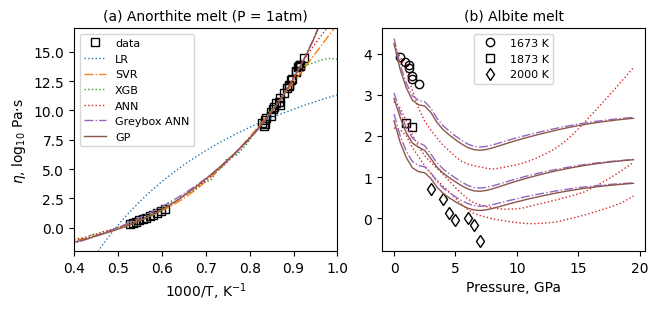

In [14]:
#
# And final figure !
#
lines = [":","-.",":",":","-.","-","-"]
names=["LR","SVR","XGB","ANN","Greybox ANN", "GP","G2008"]
colors=["C0","C1","C2","C3","C4","C5","C6"]

plt.figure(figsize=(6.69,3.22))

###
# TEMPERATURE SUBPLOT
###
plt.subplot(1,2,1)
plt.title("(a) Anorthite melt (P = 1atm)", fontsize=10)

# plotting data
plt.plot(1000/dataset_anorthite["T"], 
         dataset_anorthite["viscosity"],
         "ks", markerfacecolor="none", label="data")

# add the model of Li et al. 2021
compo_an_li = {"sio2": 50.0, 
                "na2o": 0.0, 
                "al2o3": 25.0, 
                "mgo": 0.0, 
                "cao": 25.0}
#plt.plot(1000/T_interest, li_2021_model(T_interest, 0.0, compo_an_li), 
#            linewidth=1.0,
#            linestyle="-", color="k")
# plotting predictions
for count,i in enumerate(predictions_anorthite):
    if count == 5:
        plt.plot(1000/T_interest, i[0], linestyle=lines[count], 
                 linewidth=1.0,
                 label=names[count], color=colors[count])
    else:
        plt.plot(1000/T_interest, i, linestyle=lines[count], 
                 linewidth=1.0,
                 label=names[count], color=colors[count])
        
    


plt.xlabel("1000/T, K$^{-1}$")
plt.ylabel("$\eta$, log$_{10}$ Pa$\cdot$s")
plt.legend(loc="best", fontsize=8)
plt.xlim(0.4,1.0)
plt.ylim(-2.0,17)

###
# PRESSURE SUBPLOT
###
plt.subplot(1,2,2)
plt.title("(b) Albite melt", fontsize=10)
P_interest = np.arange(0,20.,0.5)

# plotting data
plt.plot(dataset_albite_hp.loc[dataset_albite_hp["T"]==1673,"P"], 
         dataset_albite_hp.loc[dataset_albite_hp["T"]==1673, "viscosity"], "ko", 
         markerfacecolor="none", label="1673 K")
plt.plot(dataset_albite_hp.loc[dataset_albite_hp["T"]==1873,"P"], 
         dataset_albite_hp.loc[dataset_albite_hp["T"]==1873, "viscosity"], "ks", 
         markerfacecolor="none", label="1873 K")
plt.plot(dataset_albite_hp.loc[dataset_albite_hp["T"]==2000,"P"], 
         dataset_albite_hp.loc[dataset_albite_hp["T"]==2000, "viscosity"], "kd", 
         markerfacecolor="none", label="2000 K")
plt.legend(fontsize=8)

# plotting predictions
for i in [1673, 1873, 2000]:
    predictions_albite_hp_ = predict_one_compo(dataset_albite_hp.loc[dataset_albite_hp["T"]==i,:].reset_index(), 
                                               ds, i*np.ones(len(P_interest)), P_interest)

    # we only plot the interesting models
    for j in range(3,len(predictions_albite_hp_)):
        if j == 5:
            plt.plot(P_interest, predictions_albite_hp_[j][0], 
                     linewidth=1.0,
                     linestyle=lines[j], label=names[j], color=colors[j])
        else:
            plt.plot(P_interest, predictions_albite_hp_[j], 
                     linewidth=1.0,
                     linestyle=lines[j], label=names[j], color=colors[j])
    # add the model of Li et al. 2021
    compo_ab_li = {"sio2": 75.0, 
                    "na2o": 12.5, 
                    "al2o3": 12.5, 
                    "mgo": 0.0, 
                    "cao": 0.0}
    #plt.plot(P_interest, li_2021_model(i, P_interest*10**1, compo_ab_li), 
    #            linewidth=1.0,
    #            linestyle="-", color="k")
    

#plt.ylabel("$\eta$, log$_{10}$ Pa$\cdot$s")
plt.xlabel("Pressure, GPa")
plt.tight_layout()
plt.savefig("./figures/Figure_2.pdf", bbox_inches="tight")

# Figure 3

RMSE of the GP at HP (all data): 0.34


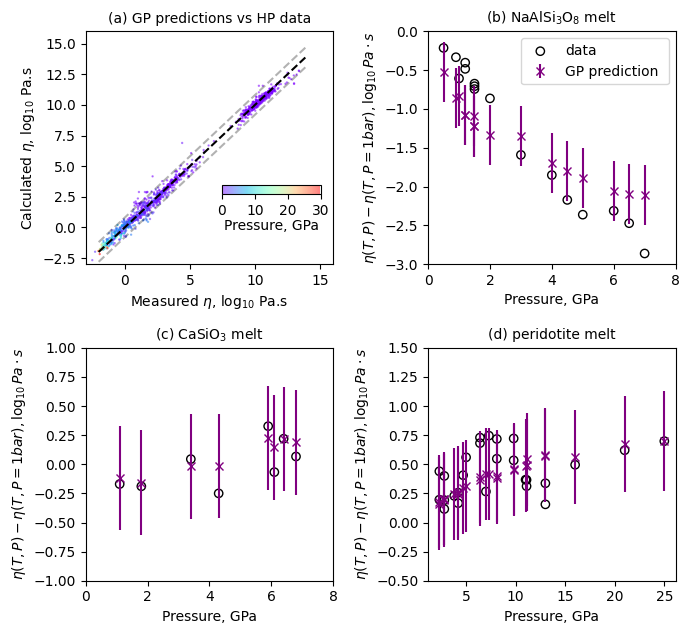

In [15]:
#
# get data and make predictions
#

dataset_peridotite = ds.dataset_hp.loc[ds.dataset_hp.Compo_interest=="peridotite",:].reset_index()
dataset_casio3 = ds.dataset_hp.loc[ds.dataset_hp.Compo_interest=="casio3",:].reset_index()
dataset_mgsio3 = ds.dataset_hp.loc[ds.dataset_hp.Compo_interest=="mgsio3",:].reset_index()
dataset_albite = ds.dataset_hp.loc[ds.dataset_hp.Compo_interest=="albite",:].reset_index()

predictions_albite = predict_one_compo(dataset_albite, ds, dataset_albite["T"].values, dataset_albite["P"].values)
predictions_casio3 = predict_one_compo(dataset_casio3, ds, dataset_casio3["T"].values, dataset_casio3["P"].values)
predictions_mgsio3 = predict_one_compo(dataset_mgsio3, ds, dataset_mgsio3["T"].values, dataset_mgsio3["P"].values)
predictions_peridotite = predict_one_compo(dataset_peridotite, ds, dataset_peridotite["T"].values, dataset_peridotite["P"].values)

#
# predict for the entire HP dataset using the Greybox ANN and GP
#

# reading and preparing the data
dataset_hp_ = gpvisc.chimie_control(ds.dataset_hp.sort_values(by="P").copy())
X_hp = gpvisc.scale_for_gaussianprocess(dataset_hp_["T"], dataset_hp_["P"], dataset_hp_)

# predict with the two models
oneC_greyhp = gpvisc.predict(X_hp, gp_model, likelihood, model_to_use="ann", device=device)
oneC_gp, oneC_gp_std = gpvisc.predict(X_hp, gp_model, likelihood, model_to_use="gp", device=device)

# root mean square error of high-pressure data
rmse_gp = root_mean_squared_error(oneC_gp, dataset_hp_["viscosity"].values)
print(f"RMSE of the GP at HP (all data): {rmse_gp:.2f}")

#
# making figure 3
#
fig = plt.figure(figsize=(7.0,6.44))
ax_hpcomp = plt.subplot(2,2,1)
plt.title("(a) GP predictions vs HP data", fontsize=10)
y_11 = np.array([-2,14])
plt.plot([-2,14],y_11,'k--',label="1:1")
# we plot the average model confidence interval on top
plt.plot([-2,14],y_11-2*np.mean(oneC_gp_std),'k--',alpha=0.3)
plt.plot([-2,14],y_11+2*np.mean(oneC_gp_std),'k--',alpha=0.3)
pcm=plt.scatter(dataset_hp_.loc[:,'viscosity'].values.reshape(-1,1),
            oneC_gp,
            cmap='rainbow',
            c=dataset_hp_.loc[:,"P"].values.reshape(-1,1),
            marker='.',
            s=2,
            alpha = 0.5
           )
plt.xlabel('Measured $\eta$, log$_{10}$ Pa.s')
plt.ylabel('Calculated $\eta$, log$_{10}$ Pa.s')
cax = ax_hpcomp.inset_axes([0.55, 0.3, 0.4, 0.04])
cbar = fig.colorbar(pcm, cax=cax, orientation='horizontal')
cbar.set_label('Pressure, GPa', labelpad=0.5)
cbar.set_ticks([0,10,20,30], labels=['0','10','20','30'])
plt.xlim(-3,16)
plt.ylim(-3,16)

ax_ab = plt.subplot(2,2,2)
plt.title("(b) NaAlSi$_3$O$_8$ melt", fontsize=10)
plt.scatter(dataset_albite.loc[:,"P"],
            dataset_albite.viscosity - (-4.5+10601/(dataset_albite.loc[:,"T"]-443.7)),  # TVF on LL2013 data
            marker='o',
            facecolor="None",
            edgecolor="k",
            label="data")
plt.errorbar(dataset_albite.loc[:,"P"],
             predictions_albite[5][0] - (-4.5+10601/(dataset_albite.loc[:,"T"]-443.7)),  # TVF on LL2013 data
             yerr = predictions_albite[5][0]-predictions_albite[5][1],
             c="purple",
             marker='x',
             linestyle="none",
             label="GP prediction ")
plt.xlabel("Pressure, GPa")
plt.ylabel("$\eta(T,P) - \eta(T,P=1bar), \log_{10} Pa\cdot s$")
plt.legend(fontsize=10)
plt.xlim(0,8)
plt.ylim(-3,0)

ax_casio3 = plt.subplot(2,2,3)
plt.title("(c) CaSiO$_3$ melt", fontsize=10)
plt.scatter(dataset_casio3.loc[:,"P"],
            dataset_casio3.viscosity - (-3.84+3454.4/(dataset_casio3.loc[:,"T"]-819.8)),  # TVF on Urbain data at 1 bar
            marker='o',
            facecolor="None",
            edgecolor="k",
            label="data")
plt.errorbar(dataset_casio3.loc[:,"P"],
             predictions_casio3[5][0]- (-3.84+3454.4/(dataset_casio3.loc[:,"T"]-819.8)), 
             yerr = predictions_casio3[5][0]-predictions_casio3[5][1],
             c="purple",
             marker='x',
             linestyle="none",
             label="GP predictions")
plt.xlabel("Pressure, GPa")
plt.ylabel("$\eta(T,P) - \eta(T,P=1bar), \log_{10} Pa\cdot s$")
plt.xlim(0,8)
plt.ylim(-1.0,1.0)

ax_pr = plt.subplot(2,2,4)
plt.title("(d) peridotite melt", fontsize=10)
plt.scatter(dataset_peridotite.loc[:,"P"],
            dataset_peridotite.viscosity - (-4.31+3703./(dataset_peridotite.loc[:,"T"]-761.7)), # TVF from Dingwell et al. 2004
            marker='o',
            facecolor="None",
            edgecolor="k",
            label="data")
plt.errorbar(dataset_peridotite.loc[:,"P"],
             predictions_peridotite[5][0]- (-4.31+3703./(dataset_peridotite.loc[:,"T"]-761.7)), # TVF from Dingwell et al. 2004
             yerr = predictions_peridotite[5][0]-predictions_peridotite[5][1],
             c="purple",
             marker='x',
             linestyle="none",
             label="GP prediction ")
plt.xlabel("Pressure, GPa")
plt.ylabel("$\eta(T,P) - \eta(T,P=1bar), \log_{10} Pa\cdot s$")
plt.ylim(-0.5,1.5)

###
# Arrange the axes
###
def arrange_axes(ax):
    # Move left y-axis and bottom x-axis to centre, passing through (0,0)
    #ax.spines['left'].set_position('center')
    #ax.spines['bottom'].set_position('center')
    
    # Eliminate upper and right axes
    #ax.spines['right'].set_color('none')
    #ax.spines['top'].set_color('none')
    
    # Show ticks in the left and lower axes only
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

plt.tight_layout()
#plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.savefig("./figures/Figure_3.pdf", bbox_inches="tight")

# Figure 4

This figure shows the extrapolation behavior of the GP models. We use three GP models because they produce different outputs when no data were present to constrain them, i.e. in the extrapolation range.

In [16]:
# load other models
gp_model, likelihood = gpvisc.load_gp_model(model_number=1, device=device)
gp_model2, likelihood2 = gpvisc.load_gp_model(model_number=2, device=device)
gp_model3, likelihood3 = gpvisc.load_gp_model(model_number=3, device=device)

# predict for the entire HP dataset using the Greybox ANN and GP
X_peridotite = gpvisc.generate_query_single(sio2=dataset_peridotite.loc[0, "sio2"],
                                     tio2=dataset_peridotite.loc[0, "tio2"],
                                     al2o3=dataset_peridotite.loc[0, "al2o3"],
                                     feo=dataset_peridotite.loc[0, "fe2o3"],
                                     mno=dataset_peridotite.loc[0, "mno"],
                                     na2o=dataset_peridotite.loc[0, "na2o"],
                                     k2o=dataset_peridotite.loc[0, "k2o"],
                                     mgo=dataset_peridotite.loc[0, "mgo"],
                                     cao=dataset_peridotite.loc[0, "cao"],
                                     p2o5=dataset_peridotite.loc[0, "p2o5"],
                                     h2o=dataset_peridotite.loc[0, "h2o"],
                                     composition_mole = True,
                                     T_init = 3000.0, T_final= 3000.0,
                                     P_init = 0.0, P_final = 100.0,
                                     control_redox = False,
                                     #fo2_init = np.log10(0.21), fo2_final = np.log10(0.21),
                                     nb_values = 200,
                                     )

TPX_peridotite = gpvisc.scale_for_gaussianprocess(X_peridotite["T"], X_peridotite["P"], X_peridotite)

# regroup models in lists
gp_models = [gp_model, gp_model2, gp_model3]
likelihoods = [likelihood, likelihood2, likelihood3]

results_mean, results_std = [], []
for i in range(1,4):
    mean_3000, std_3000 = gpvisc.predict(TPX_peridotite, gp_models[i-1], likelihoods[i-1], model_to_use="gp", device=device)
    results_mean.append(mean_3000)
    results_std.append(std_3000)

# predict as a function of composition
oxide_ranges = {
    'sio2': [100., 0.0],
    'tio2': [0.0, 0.0],
    'al2o3': [0.0, 0.0],
    "feo" :[0.0, 0.0],
    "fe2o3":[0.0,0.0],
    "mno" :[0.0,0.0],
    "na2o":[0.0, 100.],
    "k2o" :[0.0, 0.0],
    "mgo" :[0.0, 0.0],
    "cao" :[0.0, 0.0],
    "p2o5":[0.0, 0.0],
    "h2o" :[0.0, 0.0],
}

Inputs_range = gpvisc.generate_query_range(oxide_ranges, composition_mole=True,
                                    T_init=1400, T_final=1400, P_init=0.0, P_final=0.0,
                                    nb_values=200)

# transformation
ptxi_scaled = gpvisc.scale_for_gaussianprocess(Inputs_range["T"], 
                                               Inputs_range["P"], 
                                               Inputs_range[gpvisc.list_oxides()])

# predictions
NS_1_mean, NS_1_std = gpvisc.predict(ptxi_scaled, gp_model=gp_model, likelihood=likelihood, device=device)
NS_2_mean, NS_2_std = gpvisc.predict(ptxi_scaled, gp_model=gp_model2, likelihood=likelihood2, device=device)
NS_3_mean, NS_3_std = gpvisc.predict(ptxi_scaled, gp_model=gp_model3, likelihood=likelihood3, device=device)


/home/charles/miniconda3/envs/gpvisc/lib/python3.11/site-packages/gpvisc/models.py:270: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_train_valid = torch.load(model_path /

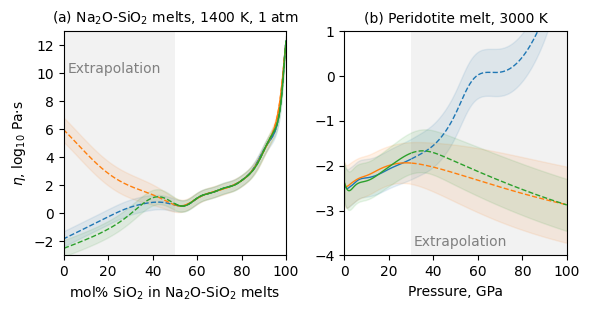

In [17]:
# Function to plot pressure-dependent results
def plot_pressure_results(ax, P_, results_mean, results_std, colors):
    for i in range(len(results_mean)):
        ax.plot(P_[P_ < 30], results_mean[i][P_ < 30], linewidth=1.0, color=colors[i], label=f"Model {i+1}")
        ax.plot(P_[P_ >= 30], results_mean[i][P_ >= 30], linestyle="--", linewidth=1.0, color=colors[i])
        ax.fill_between(P_, 
                        results_mean[i] - results_std[i],
                        results_mean[i] + results_std[i],
                        alpha=0.1, color=colors[i])
    ax.fill_betweenx([-4, 1], [30], [100], color="grey", alpha=0.1, edgecolor="None")
    ax.annotate("Extrapolation", xy=(31, -3.8), color="grey")
    ax.set_xlabel("Pressure, GPa")
    ax.set_xlim(0, 100)
    ax.set_ylim(-4, 1)
    ax.set_title("(b) Peridotite melt, 3000 K", fontsize=10)

# Function to plot SiO2-dependent results
def plot_sio2_results(ax, Inputs_range, NS_means, NS_stds, colors):
    for i, (mean, std) in enumerate(zip(NS_means, NS_stds)):
        sio2_filtered = Inputs_range.loc[Inputs_range["sio2"] > 0.5, "sio2"] * 100
        ax.plot(sio2_filtered, mean[Inputs_range["sio2"] > 0.5], linewidth=1.0, linestyle="-", color=colors[i])
        ax.plot(Inputs_range["sio2"] * 100, mean, "--", linewidth=1.0, color=colors[i], label=f"Model {i+1}")
        ax.fill_between(Inputs_range["sio2"] * 100, mean - std, mean + std, alpha=0.1, color=colors[i])
    ax.fill_betweenx([-3., 13.], [0.], [50.0], color="grey", alpha=0.1, edgecolor="None")
    ax.annotate("Extrapolation", xy=(2.0, 10.0), color="grey")
    ax.set_xlabel("mol% SiO$_2$ in Na$_2$O-SiO$_2$ melts")
    ax.set_ylabel("$\eta$, log$_{10}$ Pa$\cdot$s")
    ax.set_xlim(0, 100)
    ax.set_ylim(-3., 13.0)
    ax.set_title("(a) Na$_2$O-SiO$_2$ melts, 1400 K, 1 atm", fontsize=10)

# Main plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.22))
colors = ["C0", "C1", "C2"]

# Panel (a) - SiO2
plot_sio2_results(ax1, Inputs_range, [NS_1_mean, NS_2_mean, NS_3_mean], [NS_1_std, NS_2_std, NS_3_std], colors)

# Panel (b) - Pressure
plot_pressure_results(ax2, X_peridotite["P"].values, results_mean, results_std, colors)

# Add legends
#for ax in [ax1, ax2]:
#    ax.legend(loc="best", fontsize="small")

plt.tight_layout()
plt.savefig("./figures/Figure_4.pdf", bbox_inches="tight")
